# Film Junky Union - Sentiment Analysis
### Dr. Danisha L. Thomas

## Project Overview
This project develops a sentiment classification system for the Film Junky 
Union, a community for classic movie enthusiasts. Using a dataset of IMDB 
movie reviews with polarity labels, the goal is to train models to 
automatically detect negative reviews. The project requires a minimum 
F1 score of 0.85.

## Models Used
- Model 0: Dummy Classifier (baseline)
- Model 1: NLTK stopword removal, TF-IDF vectorization, Logistic Regression
- Model 3: spaCy lemmatization, TF-IDF vectorization, Logistic Regression
- Model 4: spaCy lemmatization, TF-IDF vectorization, LightGBM

## Key Results
- Model 1 Test F1: 0.89
- Model 3 Test F1: 0.89
- Model 4 Test F1: 0.87
- All models exceeded the 0.85 threshold

Note: BERT (Model 9) was not implemented due to computational constraints.

# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

## Initialization

In [1]:
# Import core libraries for data manipulation and visualization

import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sklearn.metrics as metrics

# Import regex for text cleaning 
import re

import nltk
import os
import spacy

from tqdm.auto import tqdm
# Enable progress_apply for pandas to show progress bars during text processing
tqdm.pandas()

from sklearn.dummy import DummyClassifier

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

from lightgbm import LGBMClassifier

# Import warning suppressions
import warnings
warnings.filterwarnings('ignore')


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

## Load Data

In [3]:
# Load the IMDB reviews dataset
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [4]:
# Check dataset shape and column names
print(df_reviews.shape)
print(df_reviews.columns.tolist())

(47331, 17)
['tconst', 'title_type', 'primary_title', 'original_title', 'start_year', 'end_year', 'runtime_minutes', 'is_adult', 'genres', 'average_rating', 'votes', 'review', 'rating', 'sp', 'pos', 'ds_part', 'idx']


In [5]:
# Check for missing values
print(df_reviews.isnull().sum())

tconst             0
title_type         0
primary_title      0
original_title     0
start_year         0
end_year           0
runtime_minutes    0
is_adult           0
genres             0
average_rating     2
votes              2
review             0
rating             0
sp                 0
pos                0
ds_part            0
idx                0
dtype: int64


## EDA

Let's check the number of movies and reviews over years.

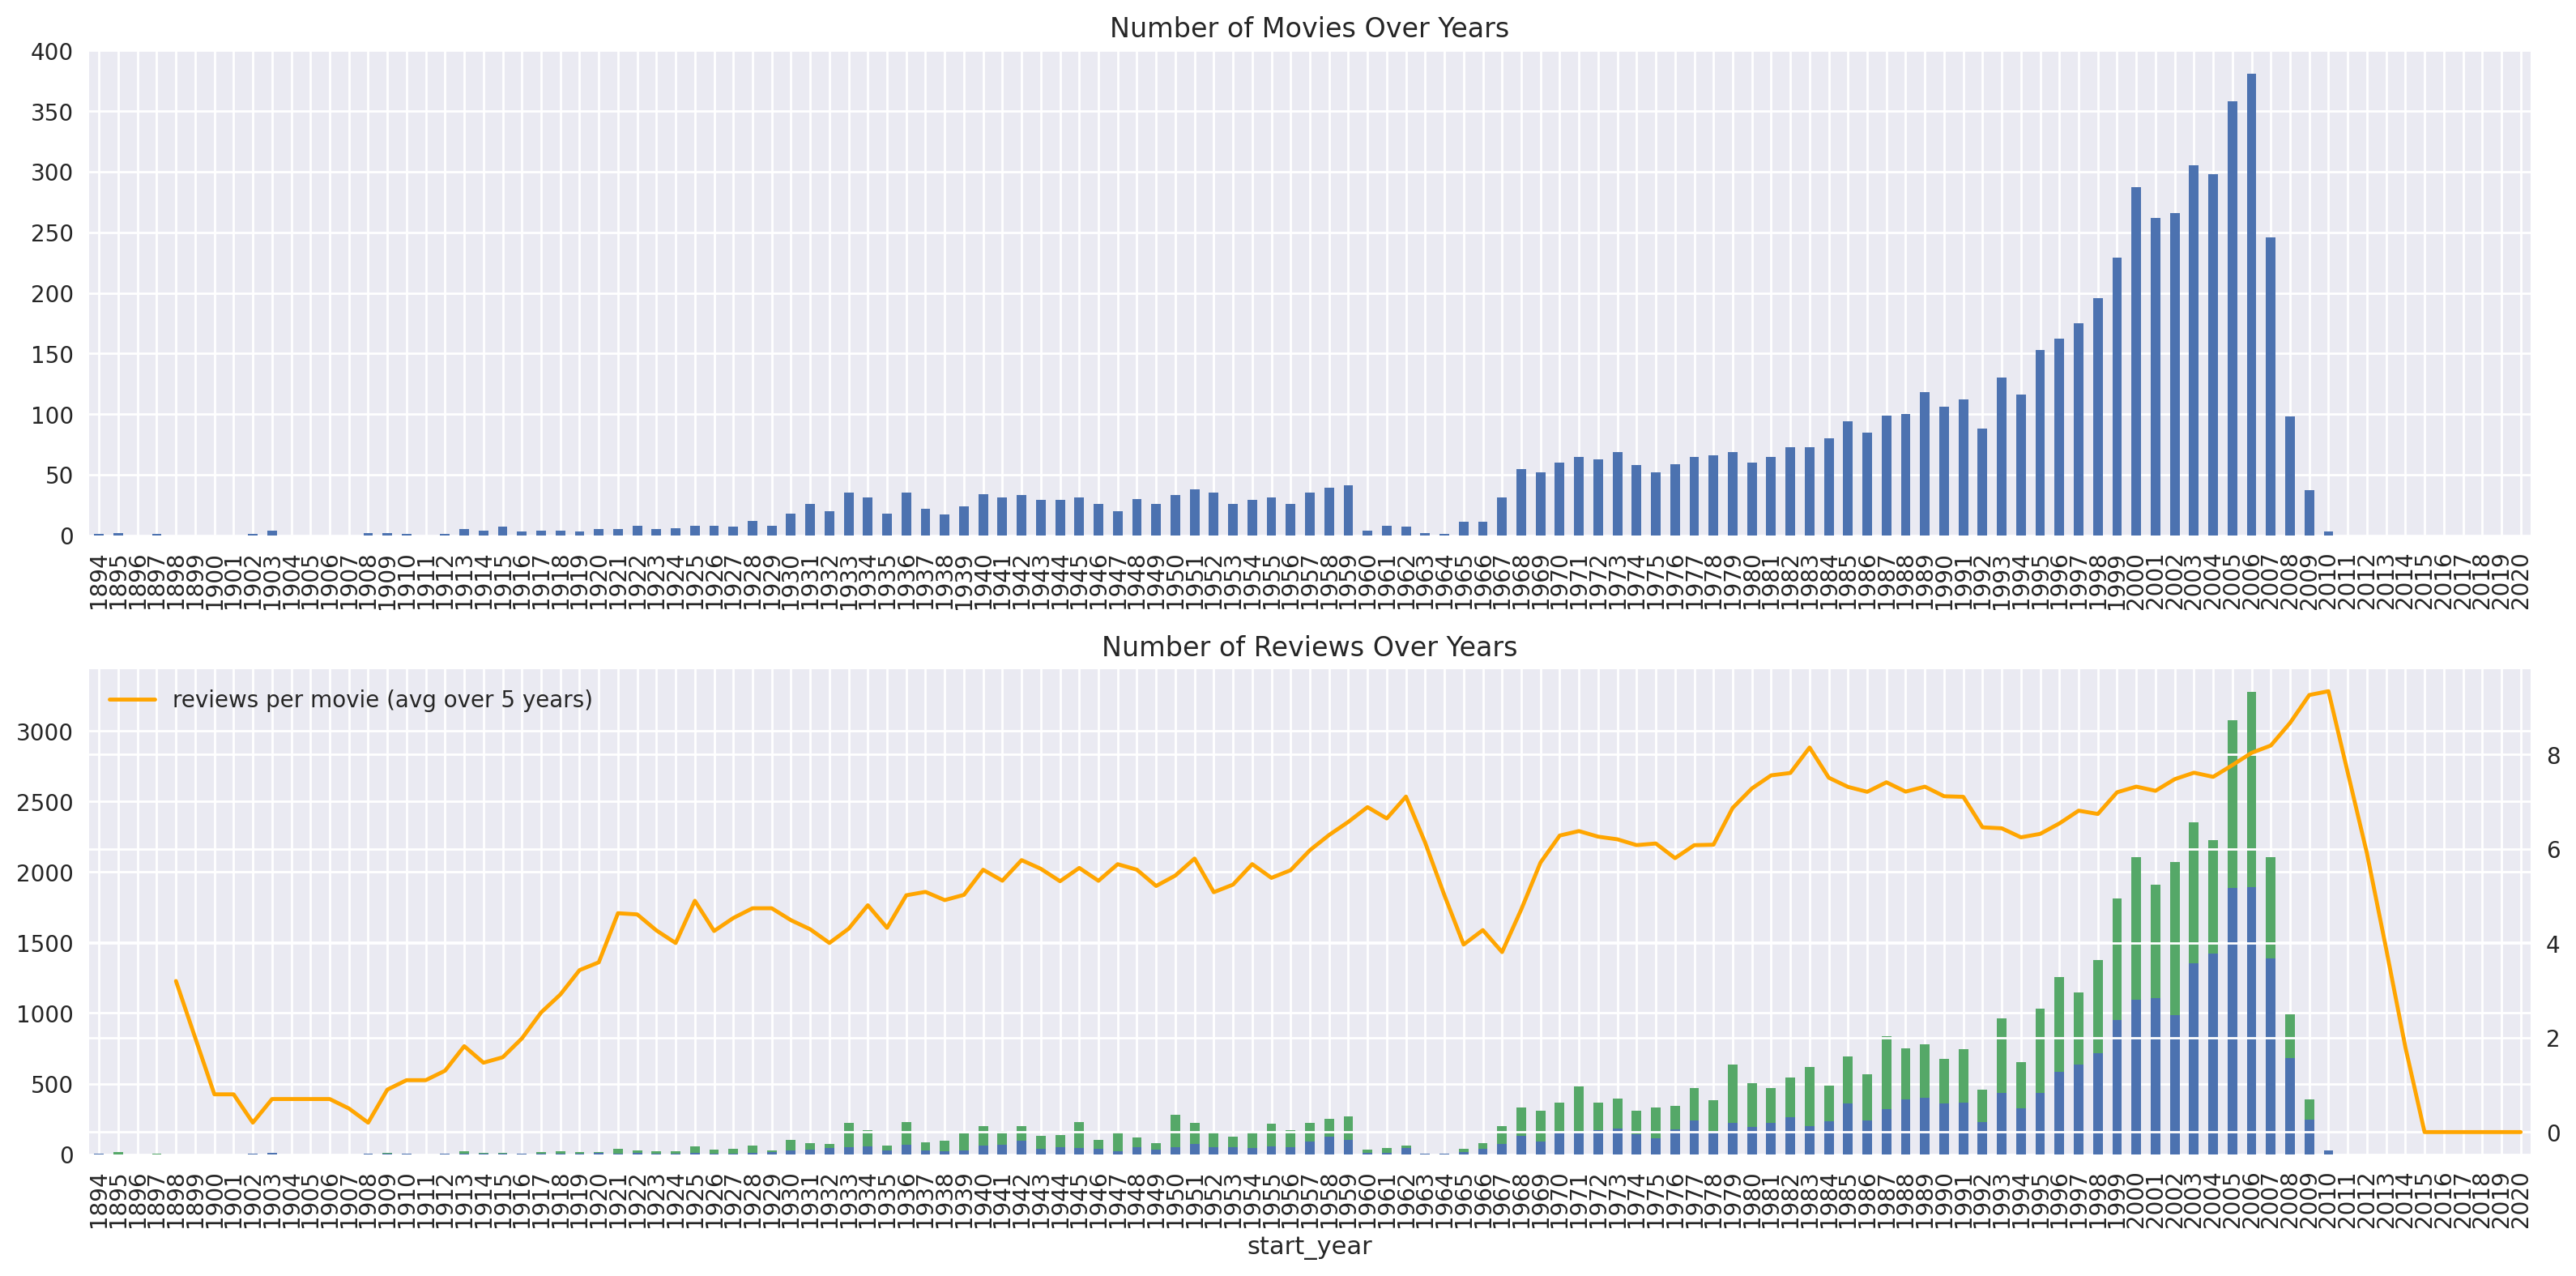

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

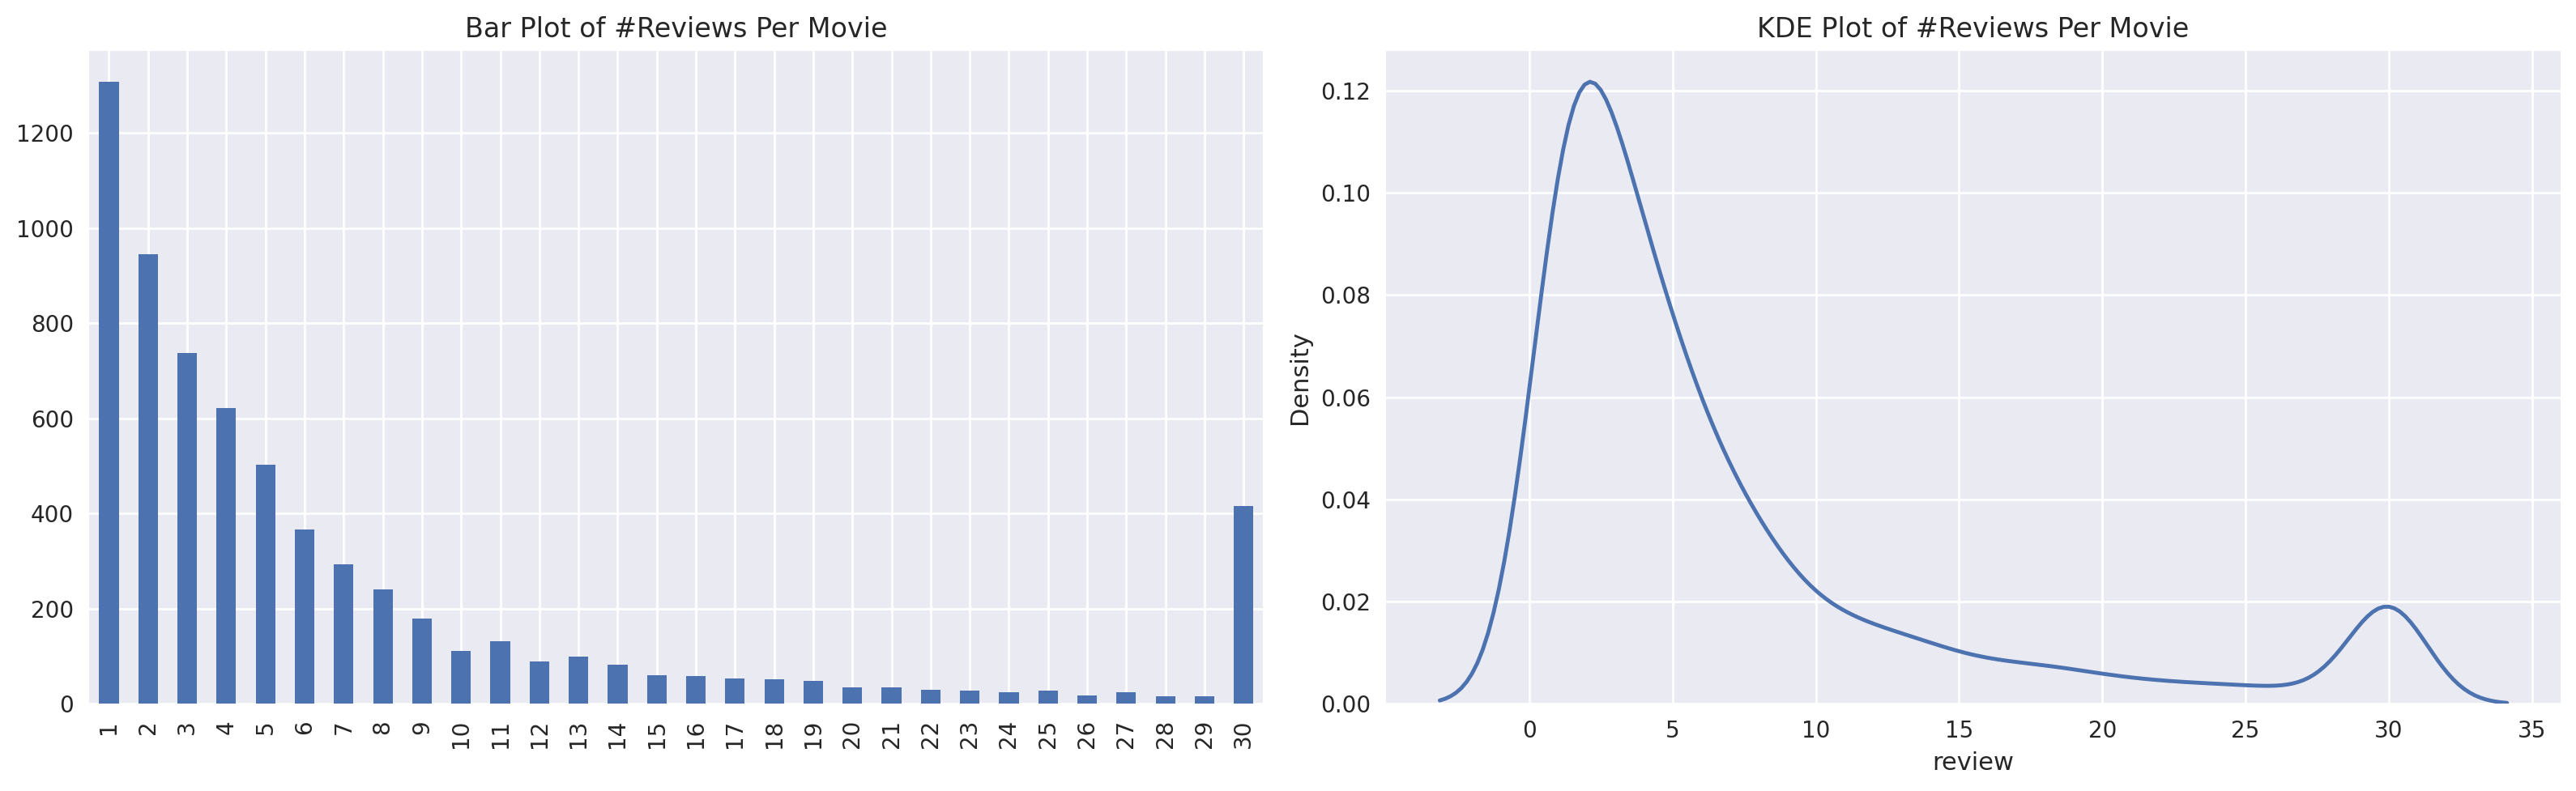

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

### EDA Observations

The dataset contains 47,331 total reviews. The class distribution is nearly 
perfectly balanced: 23,715 negative reviews (pos=0) and 23,616 positive 
reviews (pos=1). This difference of less than 0.5% means class imbalance 
is not a concern for this project, and no special techniques such as 
oversampling or class weighting is needed.

The "Number of Movies Over Years" chart shows that films in this dataset 
are heavily concentrated from the 1990s onward, with a sharp drop-off 
near the present. That drop-off reflects the time it takes for reviews 
to accumulate on IMDB rather than an actual decline in film production.

The "Bar Plot of Reviews Per Movie" shows that most movies received only 
1-3 reviews, with very few movies accumulating 20 or more. The distribution 
has a long tail to the right, meaning a small number of movies received 
a disproportionately large number of reviews.

In [8]:
# Check class balance between positive and negative reviews
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

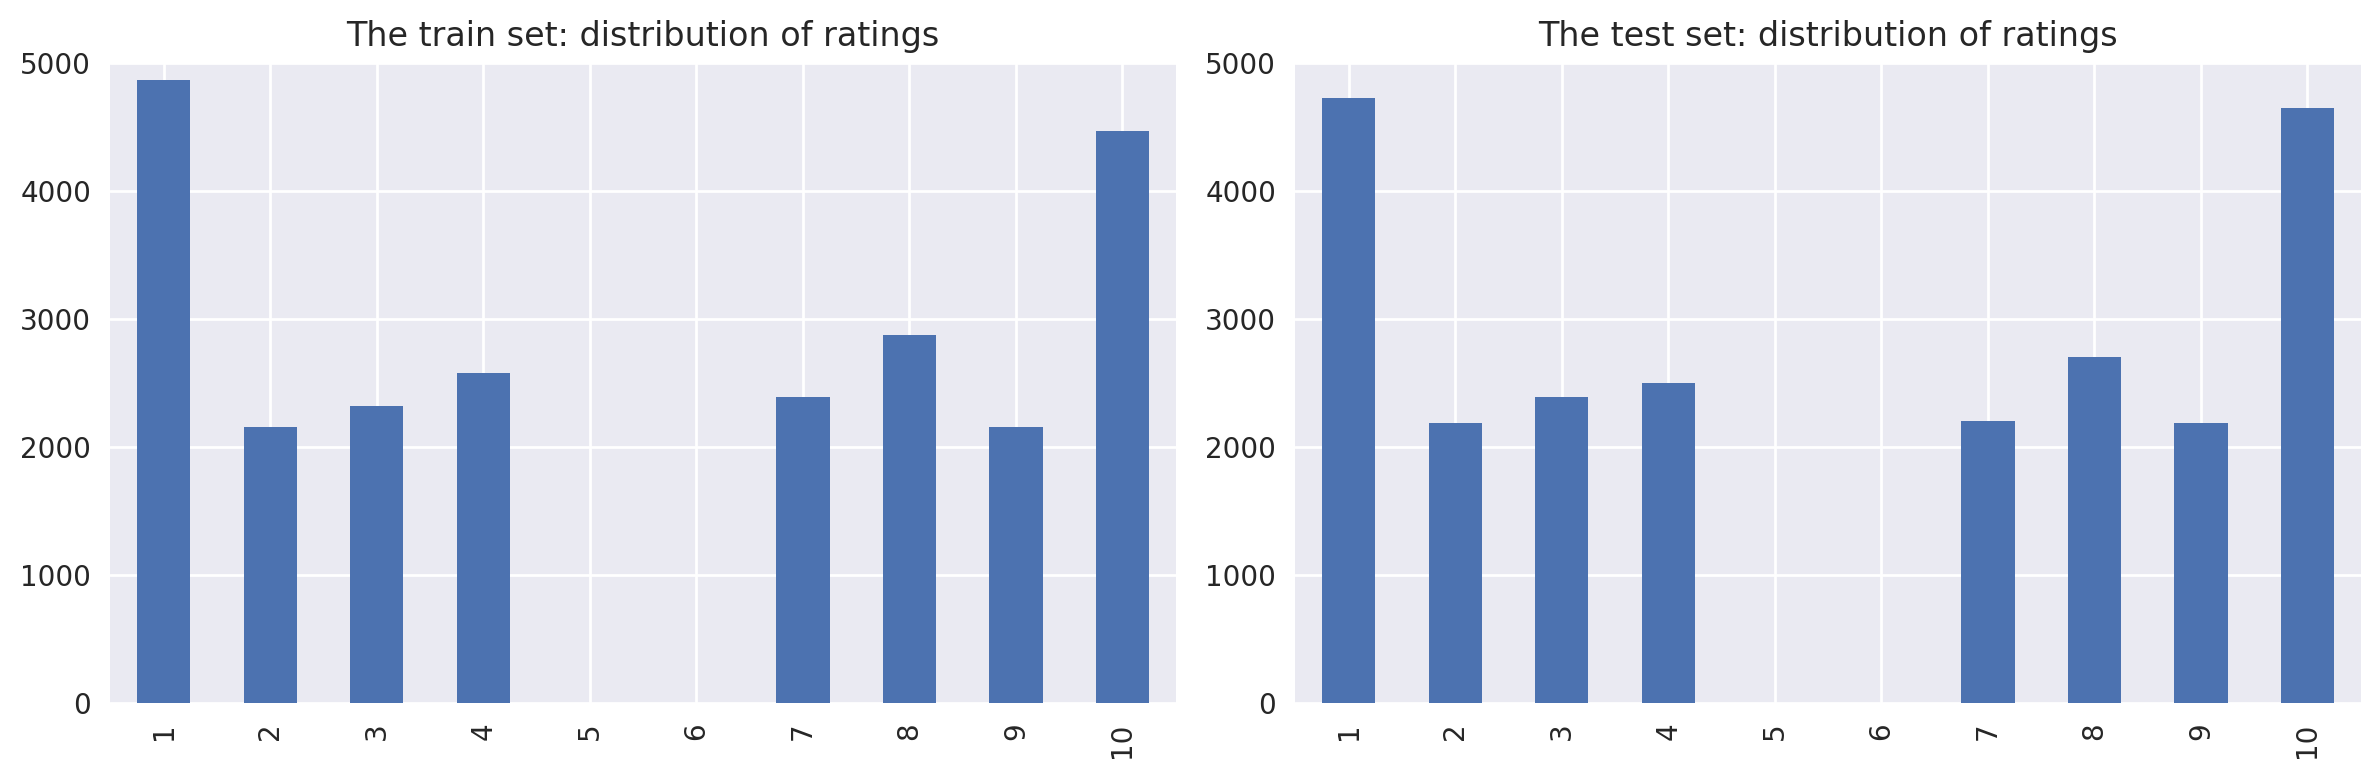

In [9]:
# Visualize rating distributions for train and test sets
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

### Findings

The "distribution of ratings" charts show a bimodal pattern in both the 
train and test sets, with the highest bar counts at ratings 1-2 and 8-10 
on a scale of 1 to 10, and a valley in the middle. This reflects the 
tendency for people to write reviews when they feel strongly in either direction.

The side-by-side train and test rating distribution charts show nearly 
identical shapes, which confirms that the pre-existing split in the 
ds_part column is reliable and representative. Hence, no bias was introduced 
in how the data was divided.

Distribution of negative and positive reviews over the years for two parts of the dataset

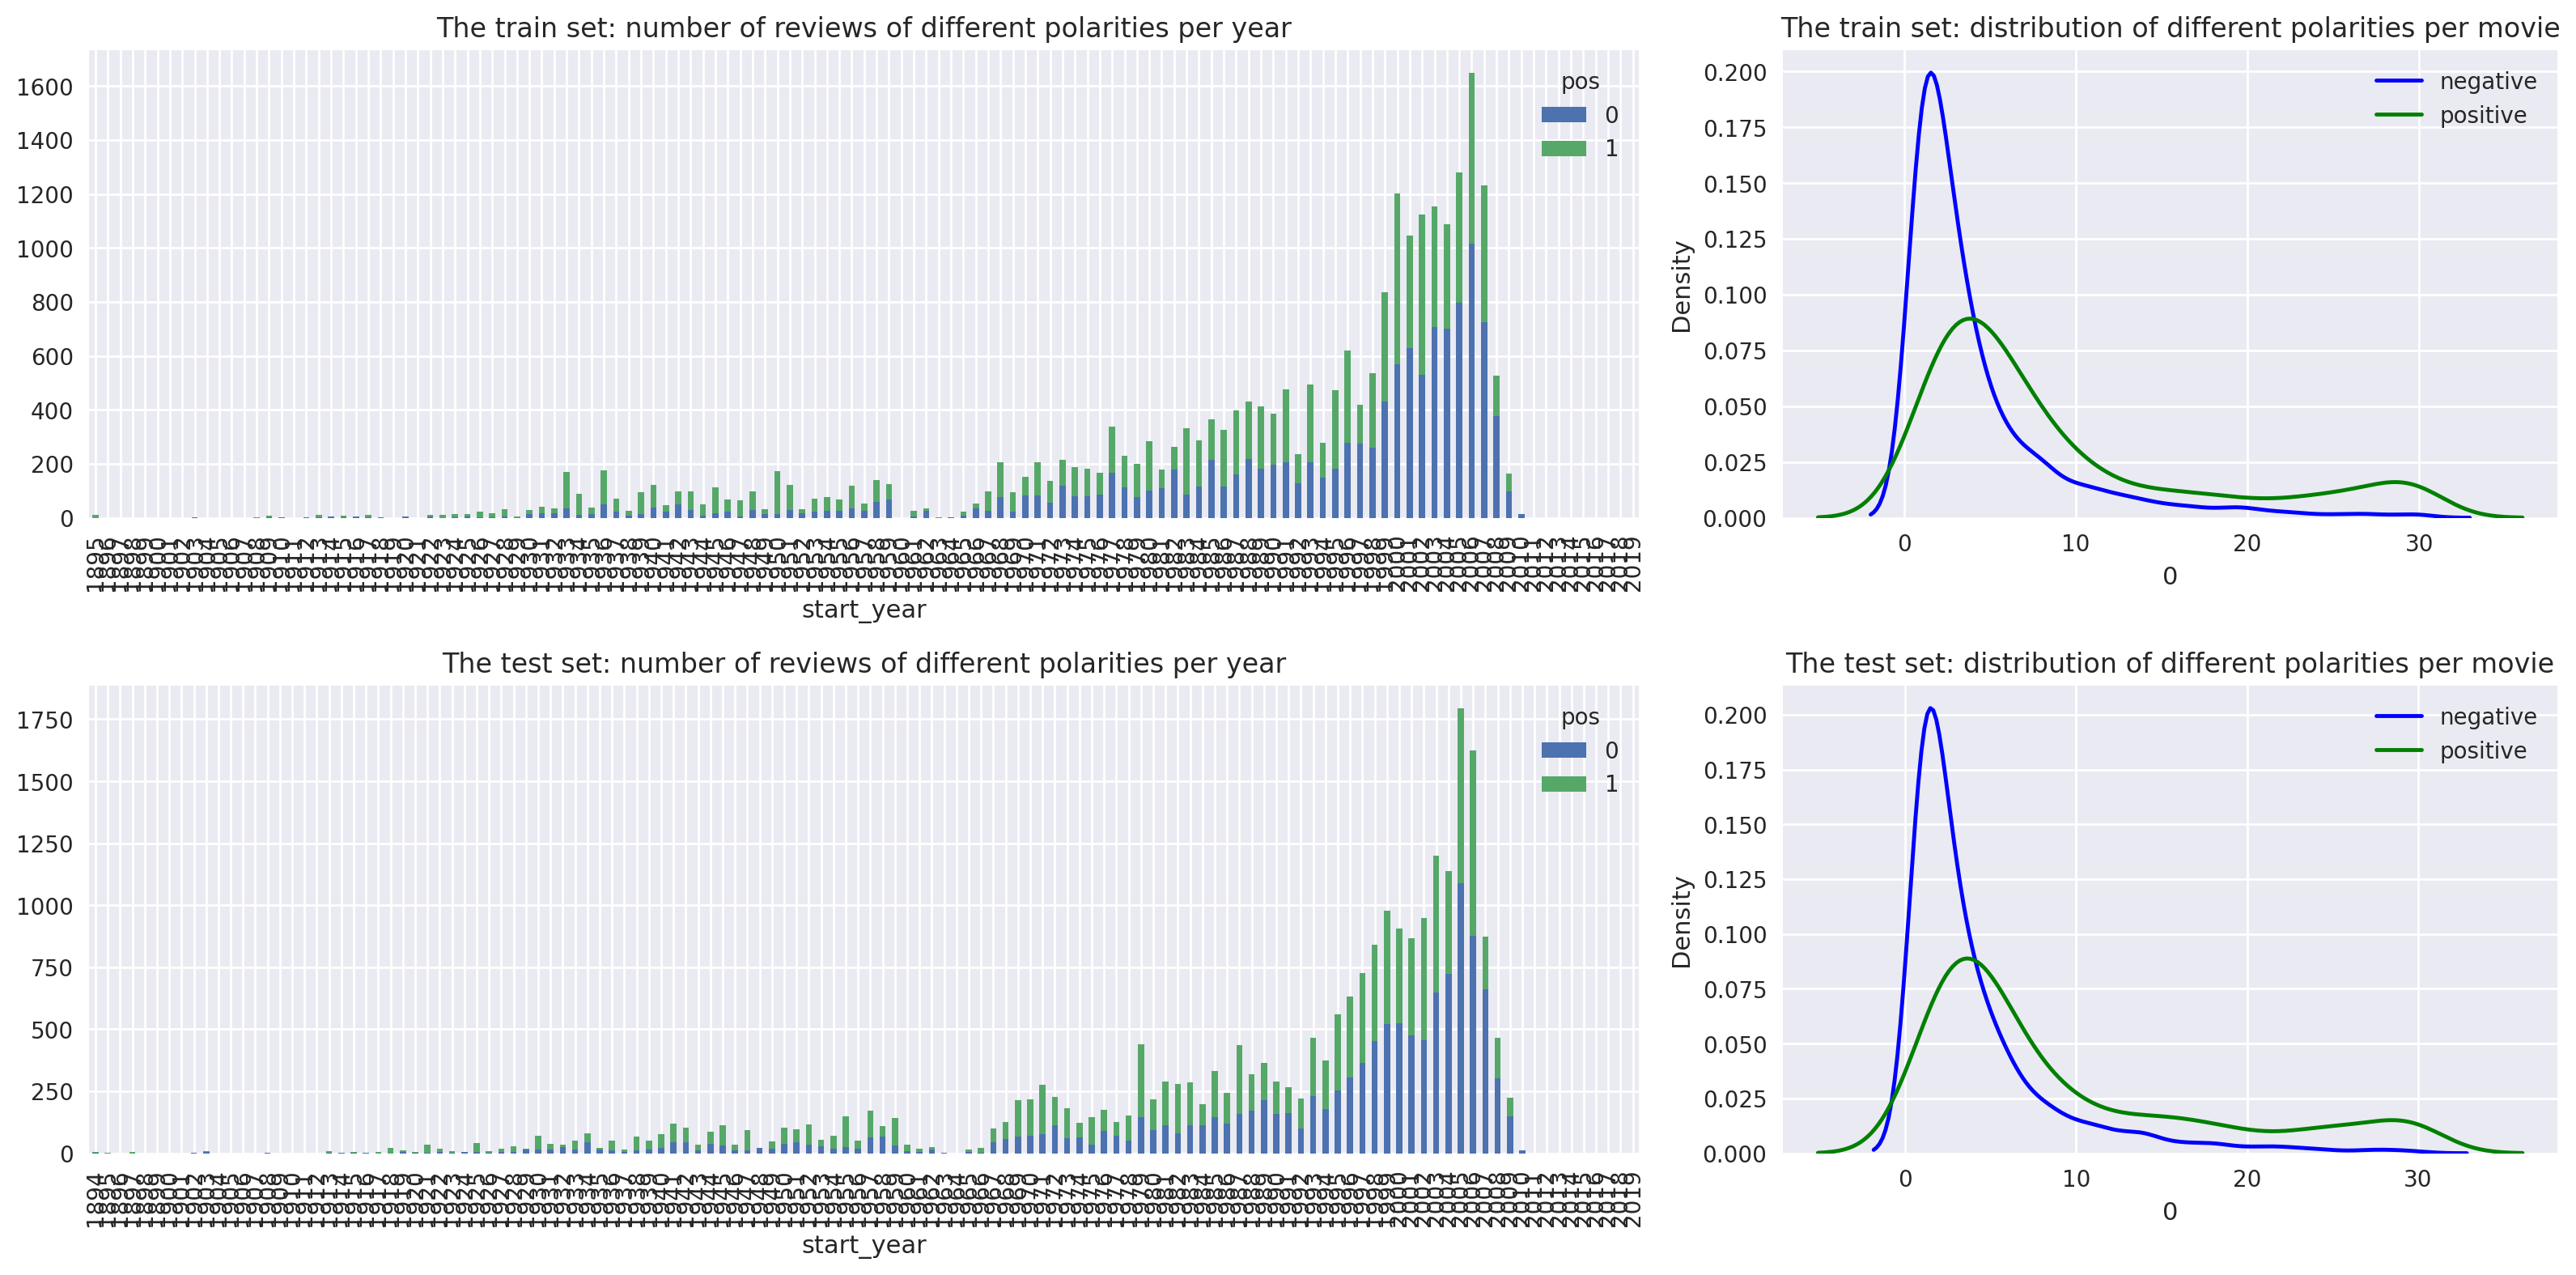

In [10]:
# Visualize distribution of positive and negative reviews over years for train and test sets

fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

### Findings

The stacked bar charts show that both negative and positive reviews 
increased significantly from the late 1990s onward in both the train 
and test sets. The positive and negative classes remain roughly 
proportional across all years.

Furthermore, the KDE plots show that negative reviews have a higher density at 
lower review counts per movie compared to positive reviews, suggesting 
that movies with fewer reviews tend to skew negative. However, this 
does not affect the overall class balance, which remains nearly equal 
at 23,715 negative and 23,616 positive reviews across the full dataset.

## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [11]:
def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

## Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [12]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove anything that is not a lowercase letter or whitespace
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Collapse multiple spaces into one
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_reviews['review_norm'] = df_reviews['review'].apply(clean_text)

# Verify it worked
pd.set_option('display.max_colwidth', 50)
df_reviews[['review', 'review_norm']].head(3)

,review,review_norm
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made presenting...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...


## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [13]:
# Split dataset into train and test sets using the existing ds_part column
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Working with models

### Model 0 - Constant

In [14]:
# Baseline model that predicts the most frequent class - used to establish a performance floor
model_0 = DummyClassifier(strategy='most_frequent', random_state=42)
model_0.fit(df_reviews_train['review_norm'], train_target)

DummyClassifier(random_state=42, strategy='most_frequent')

          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5


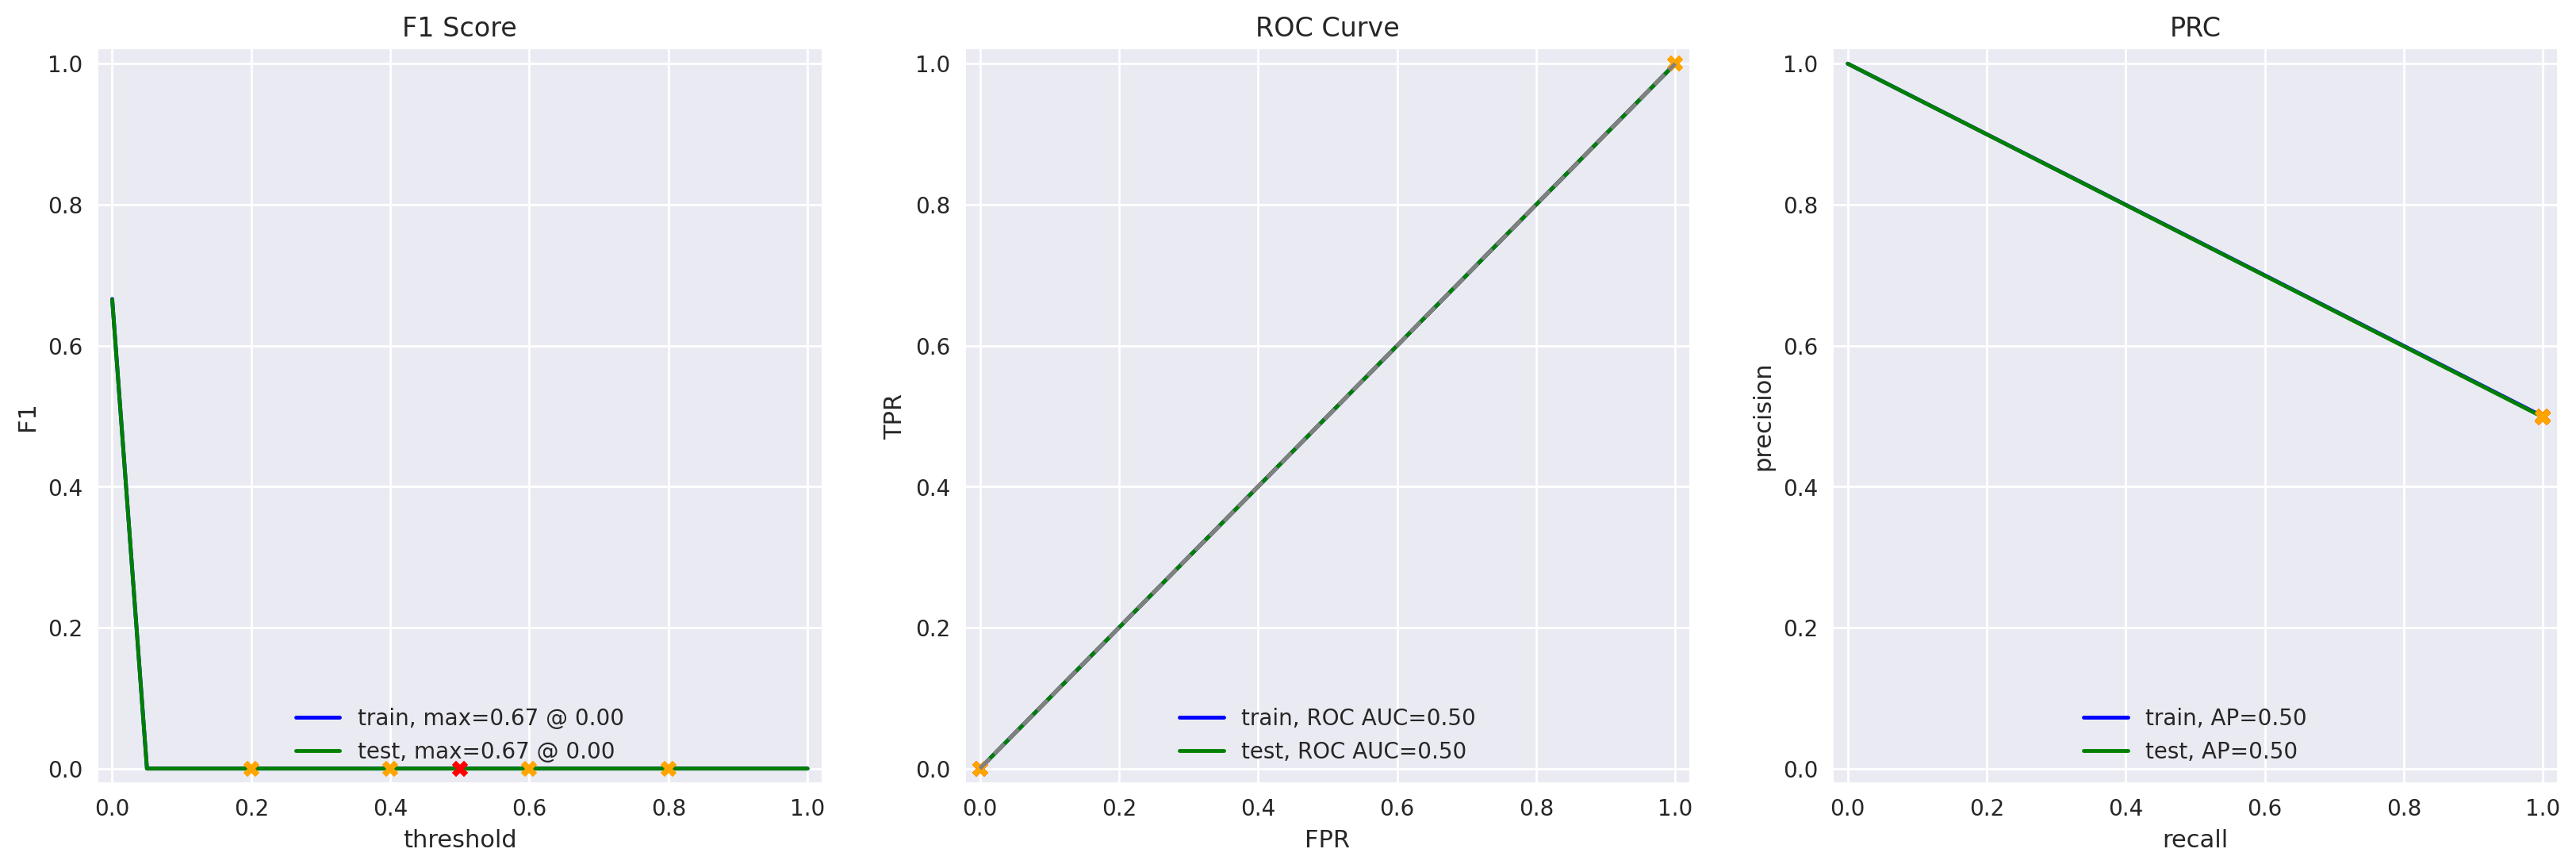

In [15]:
# Evaluate baseline model performance
evaluate_model(model_0, df_reviews_train['review_norm'], train_target,
               df_reviews_test['review_norm'], test_target)

### Model 0 Observations

The Dummy Classifier serves as our baseline. With an F1 score of 0.0 
and an accuracy of 0.50, it performs no better than random chance, 
which is expected given that it ignores the review text entirely and 
simply predicts the most frequent class every time. The ROC AUC of 
0.50 confirms this, as a score of 0.50 represents a classifier with 
no discriminative ability. Any meaningful model must significantly 
exceed these scores to be considered useful. This baseline gives us 
a floor against which all subsequent models will be measured.

### Model 1 - NLTK, TF-IDF and LR

TF-IDF

In [16]:
# Download NLTK stopwords and load English stopword list
nltk.download('stopwords', quiet=True)
stop_words = stopwords.words('english')

In [17]:
# Vectorize text using TF-IDF with unigrams and bigrams, removing stopwords
tfidf_vectorizer_1 = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1, 2),
    stop_words=stop_words
)

train_features_1 = tfidf_vectorizer_1.fit_transform(df_reviews_train['review_norm'])
test_features_1 = tfidf_vectorizer_1.transform(df_reviews_test['review_norm'])

In [18]:
# Train Logistic Regression classifier
model_1 = LogisticRegression(max_iter=1000, random_state=42)
model_1.fit(train_features_1, train_target)

LogisticRegression(max_iter=1000, random_state=42)

          train  test
Accuracy   0.95  0.89
F1         0.95  0.89
APS        0.99  0.95
ROC AUC    0.99  0.96


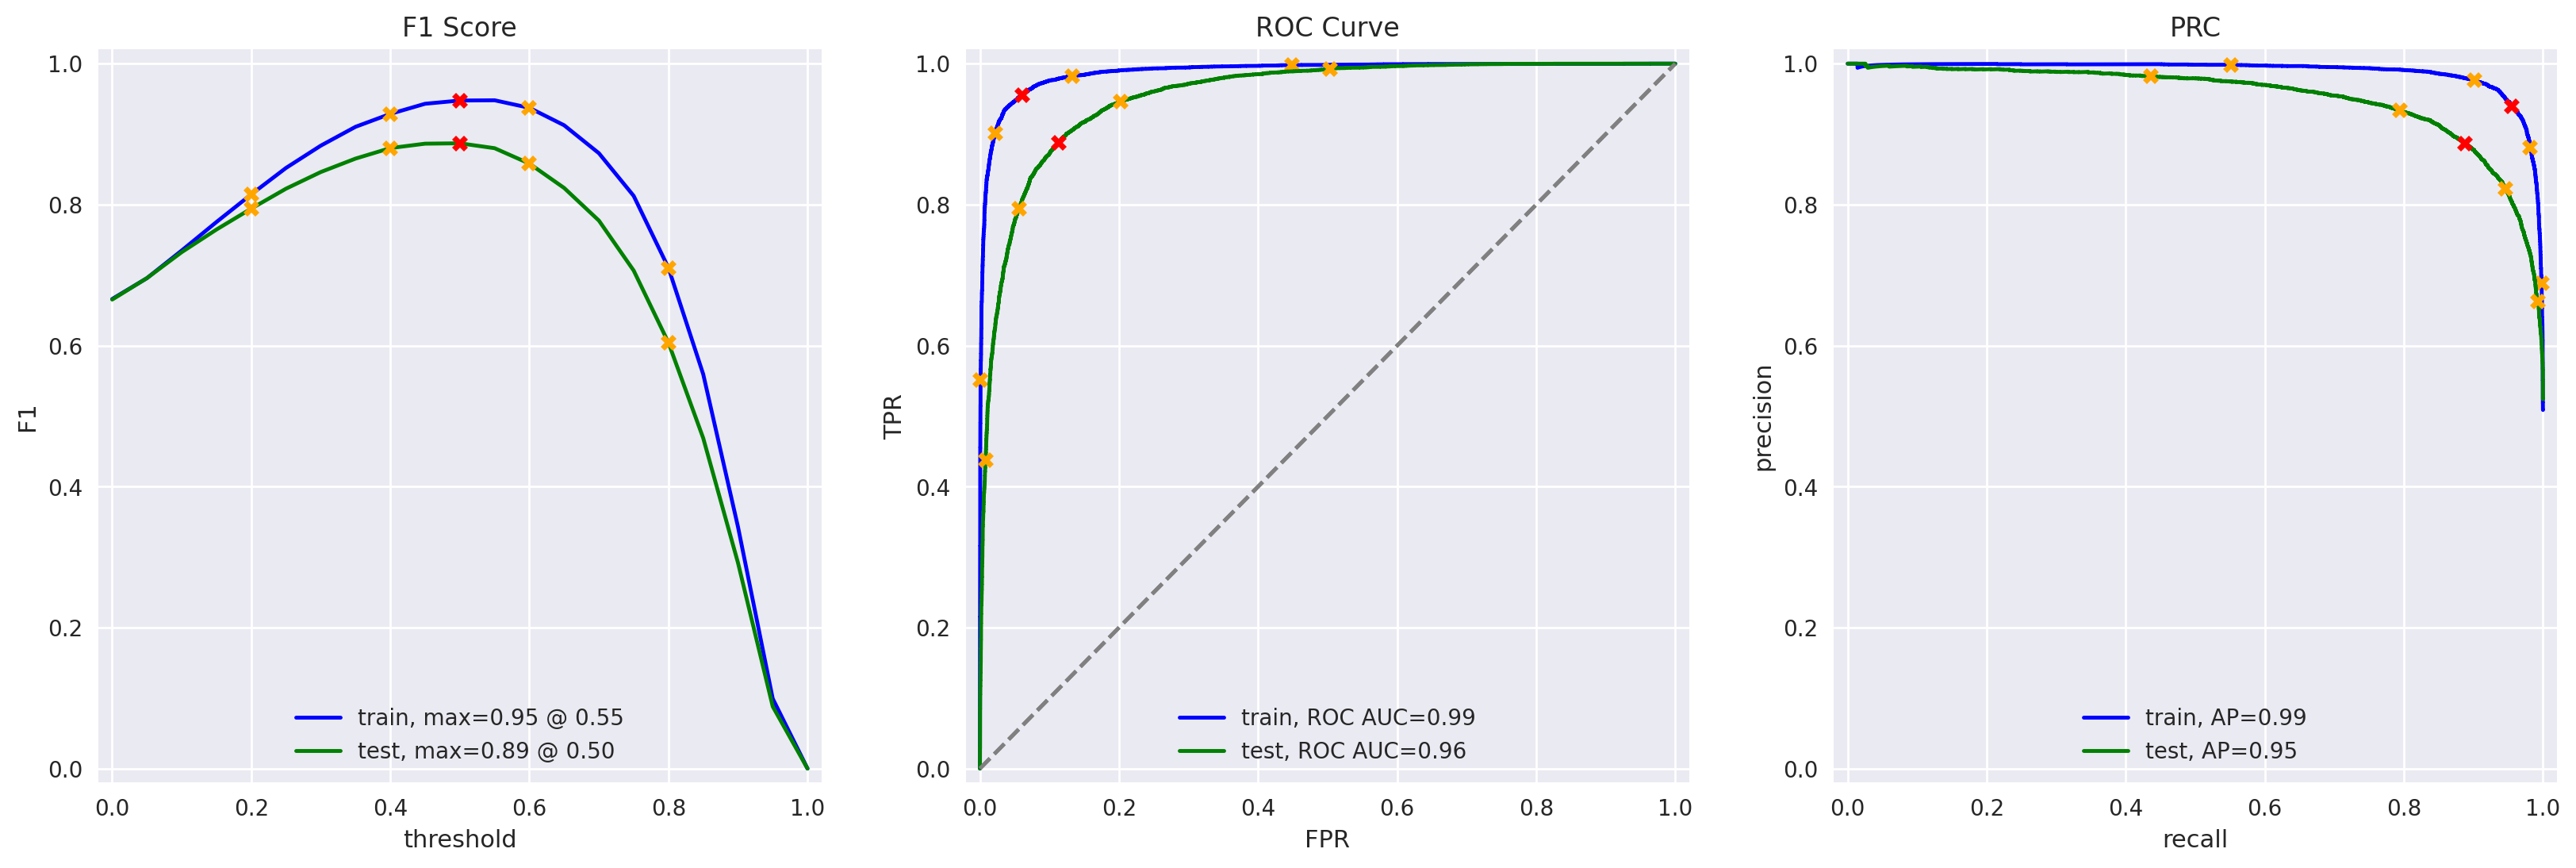

In [19]:
# Evaluate Model 1 performance
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

### Model 1 Observations

Model 1 uses NLTK stopword removal, TF-IDF vectorization with unigrams 
and bigrams, and Logistic Regression. It achieves a train F1 of 0.95 
and a test F1 of 0.89, comfortably exceeding the 0.85 threshold. 
The small gap between train and test performance suggests mild 
overfitting, but the model generalizes well to unseen data. The ROC 
AUC of 0.96 on the test set confirms strong discriminative ability 
between positive and negative reviews.

### Model 3 - spaCy, TF-IDF and LR

In [20]:
# Load spaCy English model with only tagger enabled for lemmatization
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [21]:
# Define lemmatization function using spaCy
def text_preprocessing_3(text):
    
    doc = nlp(text)
    #tokens = [token.lemma_ for token in doc if not token.is_stop]
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)

In [22]:
# Apply lemmatization to train and test sets
df_reviews_train['review_norm_3'] = df_reviews_train['review_norm'].progress_apply(text_preprocessing_3)
df_reviews_test['review_norm_3'] = df_reviews_test['review_norm'].progress_apply(text_preprocessing_3)

  0%|          | 0/23796 [00:00<?, ?it/s]

  0%|          | 0/23535 [00:00<?, ?it/s]

In [23]:
# Vectorize lemmatized text using TF-IDF with unigrams and bigrams
# Note: stopwords not removed here since spaCy lemmatization already reduces noise
tfidf_vectorizer_3 = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1, 2)
)

train_features_3 = tfidf_vectorizer_3.fit_transform(df_reviews_train['review_norm_3'])
test_features_3 = tfidf_vectorizer_3.transform(df_reviews_test['review_norm_3'])

In [24]:
# Train Logistic Regression classifier on lemmatized features
model_3 = LogisticRegression(max_iter=1000, random_state=42)
model_3.fit(train_features_3, train_target)

LogisticRegression(max_iter=1000, random_state=42)

          train  test
Accuracy   0.95  0.89
F1         0.95  0.89
APS        0.99  0.96
ROC AUC    0.99  0.96


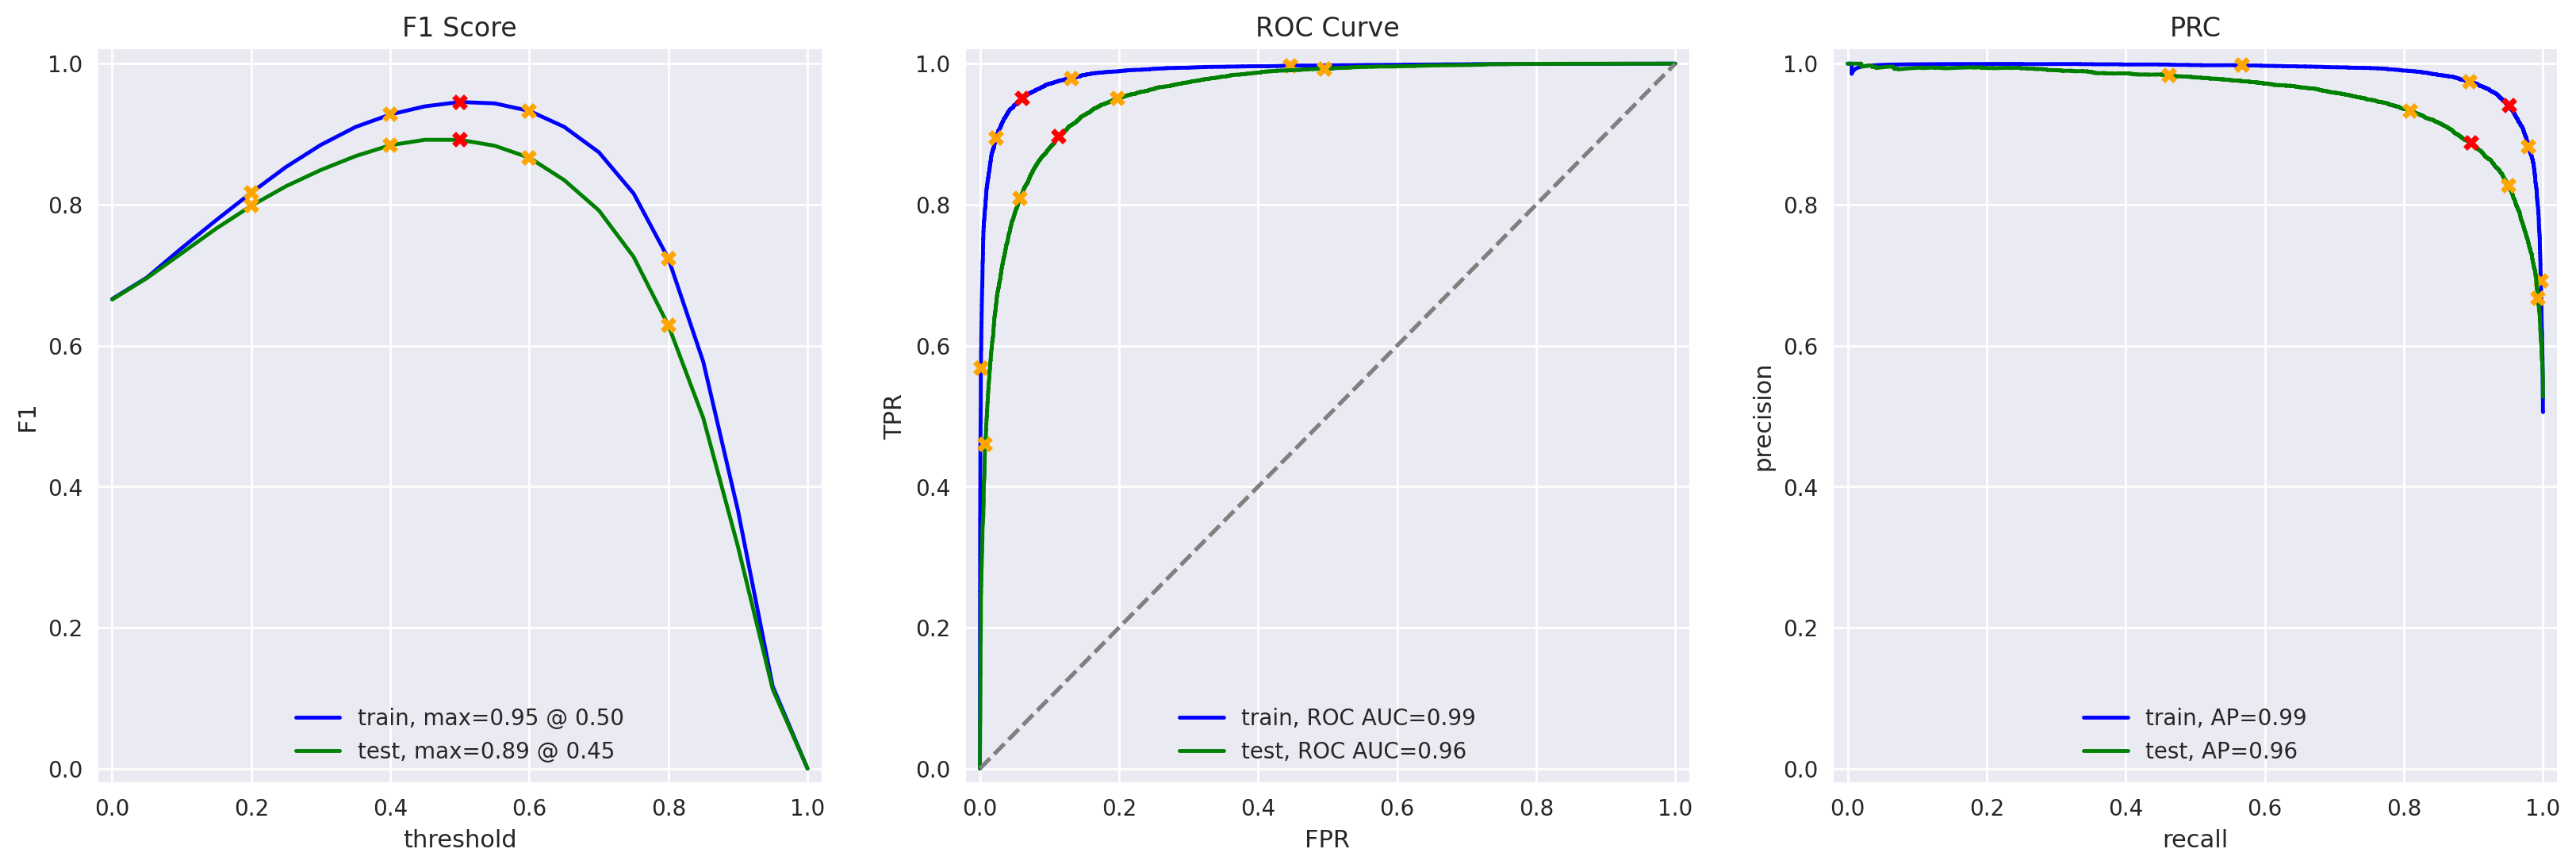

In [25]:
# Evaluate Model 3 performance
evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)

## Model 3 Observations

Model 3 uses spaCy lemmatization, TF-IDF vectorization with unigrams 
and bigrams, and Logistic Regression. It achieves a train F1 of 0.95 
and a test F1 of 0.89, identical to Model 1. This suggests that 
lemmatization did not provide additional predictive value over simple 
stopword removal for this dataset. Both models perform equally well on the test set, 
exceeding the 0.85 threshold. The ROC AUC of 0.96 on the test set matches Model 1 as well, 
confirming that the choice of text preprocessing method had minimal impact on overall performance.

### Model 4 - spaCy, TF-IDF and LGBMClassifier

In [26]:
# Model 4 uses the same spaCy lemmatized features as Model 3
# This allows a direct comparison between Logistic Regression and LightGBM
# using identical input features, isolating the effect of the classifier
train_features_4 = train_features_3
test_features_4 = test_features_3
tfidf_vectorizer_4 = tfidf_vectorizer_3

In [27]:
# Train LightGBM classifier on lemmatized features
model_4 = LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_4.fit(train_features_4, train_target)

LGBMClassifier(random_state=42)

          train  test
Accuracy   0.93  0.87
F1         0.93  0.87
APS        0.98  0.94
ROC AUC    0.98  0.94


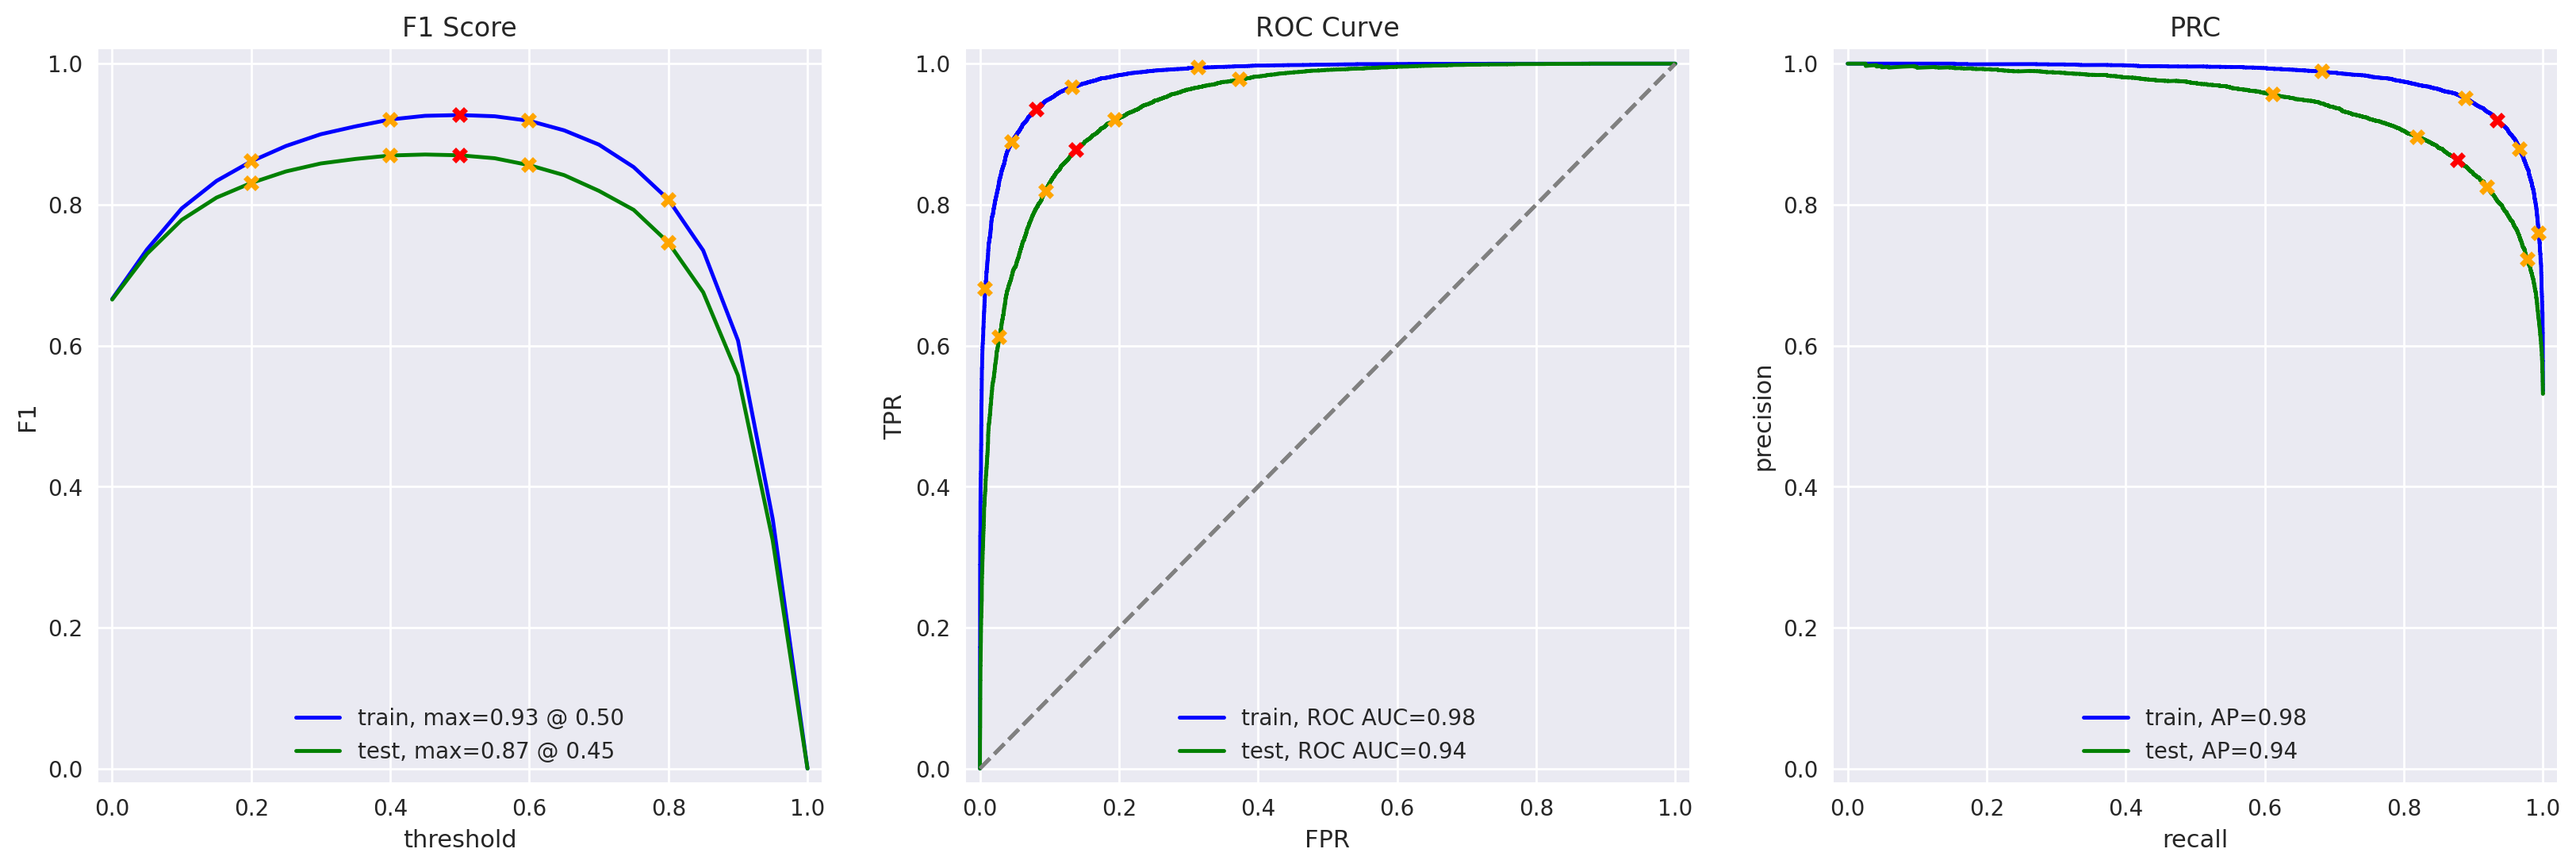

In [28]:
# Evaluate Model 4 performance
evaluate_model(model_4, train_features_4, train_target, test_features_4, test_target)

## Model 4 Observations

Model 4 uses the same spaCy lemmatization and TF-IDF features as 
Model 3 but replaces Logistic Regression with LightGBM. It achieves 
a train F1 of 0.93 and a test F1 of 0.87, which exceeds the 0.85 
threshold but performs slightly below Models 1 and 3. The larger gap 
between train and test scores compared to the Logistic Regression 
models suggests that LightGBM overfits more on this dataset. Despite using 
the same features, switching the classifier resulted in a small 
but noticeable drop in test performance.

## My Reviews

In [29]:
# Create dataframe of custom reviews for model testing
my_reviews = pd.DataFrame([
    'I enjoyed the film, it was well made.',
    'Ha, what a joke. I wish I could get my time and money back.',
    'The actors were amazing. Award winning performances by all.',
    'If I could give this a negative and a barrel of rotten eggs I would. Everything was boring.',
    'Hated it.',
    'This movie will go in my top 5 of best films ever. Everything from the acting to the cinematography was excellent!',
    'Hmm. I don\'t know. Interesting film.',
], columns=['review'])

# Apply same normalization as main dataset
my_reviews['review_norm'] = my_reviews['review'].apply(clean_text)
my_reviews

,review,review_norm
0,"I enjoyed the film, it was well made.",i enjoyed the film it was well made
1,"Ha, what a joke. I wish I could get my time an...",ha what a joke i wish i could get my time and ...
2,The actors were amazing. Award winning perform...,the actors were amazing award winning performa...
3,If I could give this a negative and a barrel o...,if i could give this a negative and a barrel o...
4,Hated it.,hated it
5,This movie will go in my top 5 of best films e...,this movie will go in my top of best films eve...
6,Hmm. I don't know. Interesting film.,hmm i don t know interesting film


### Model 1

In [30]:
# Model 1 predictions on custom reviews
texts = my_reviews['review_norm']
my_reviews_pred_prob_1 = model_1.predict_proba(tfidf_vectorizer_1.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob_1[i]:.2f}: {review}')

0.95: i enjoyed the film it was well made
0.12: ha what a joke i wish i could get my time and money back
0.86: the actors were amazing award winning performances by all
0.10: if i could give this a negative and a barrel of rotten eggs i would everything was boring
0.27: hated it
0.85: this movie will go in my top of best films ever everything from the acting to the cinematography was
0.36: hmm i don t know interesting film


### Model 3

In [31]:
# Model 3 predictions on custom reviews
texts = my_reviews['review_norm']

my_reviews_pred_prob_3 = model_3.predict_proba(tfidf_vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob_3[i]:.2f}:  {review}')

0.93:  i enjoyed the film it was well made
0.17:  ha what a joke i wish i could get my time and money back
0.88:  the actors were amazing award winning performances by all
0.21:  if i could give this a negative and a barrel of rotten eggs i would everything was boring
0.49:  hated it
0.93:  this movie will go in my top of best films ever everything from the acting to the cinematography was
0.35:  hmm i don t know interesting film


### Model 4

In [32]:
# Model 4 predictions on custom reviews
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tfidf_vectorizer_3
my_reviews_pred_prob_4 = model_4.predict_proba(tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob_4[i]:.2f}:  {review}')

0.87:  i enjoyed the film it was well made
0.50:  ha what a joke i wish i could get my time and money back
0.86:  the actors were amazing award winning performances by all
0.44:  if i could give this a negative and a barrel of rotten eggs i would everything was boring
0.75:  hated it
0.96:  this movie will go in my top of best films ever everything from the acting to the cinematography was
0.53:  hmm i don t know interesting film


## My Reviews - Model Comparison

| Review | Model 1 | Model 3 | Model 4 |
|--------|---------|---------|---------|
| i enjoyed the film it was well made | 0.95 | 0.93 | 0.87 |
| ha what a joke i wish i could get my time and money back | 0.12 | 0.17 | 0.50 |
| the actors were amazing award winning performances by all | 0.86 | 0.88 | 0.86 |
| if i could give this a negative and a barrel of rotten eggs | 0.10 | 0.21 | 0.44 |
| hated it | 0.27 | 0.49 | 0.75 |
| this movie will go in my top of best films ever | 0.85 | 0.93 | 0.96 |
| hmm i don t know interesting film | 0.36 | 0.35 | 0.53 |

All three models generally agree on clearly positive or clearly negative 
reviews. For example, the best films ever review scores consistently high across 
all models, and the time and money back review scores consistently low. However, 
Model 4 assigns noticeably higher probabilities across most reviews 
compared to Models 1 and 3, suggesting it is more generous in predicting 
positive sentiment. This is particularly evident with "hated it," where 
Model 4 scored 0.75 compared to 0.27 and 0.49 for Models 1 and 3. 
Models 1 and 3 produce very similar scores to each other, which is 
consistent with their identical F1 scores on the test set.

## Conclusions

This project built and evaluated four models for classifying positive 
and negative IMDB movie reviews, with a target F1 score of at least 0.85.

The results are summarized below:

| Model | Train F1 | Test F1 |
|-------|----------|---------|
| Model 0 - Dummy Classifier | 0.00 | 0.00 |
| Model 1 - NLTK, TF-IDF, LR | 0.95 | 0.89 |
| Model 3 - spaCy, TF-IDF, LR | 0.95 | 0.89 |
| Model 4 - spaCy, TF-IDF, LightGBM | 0.93 | 0.87 |

All three real models exceeded the 0.85 F1 threshold. Models 1 and 3 
performed identically, suggesting that spaCy lemmatization did not 
provide additional value over NLTK stopword removal for this dataset. 
Model 4 showed slightly more overfitting than the Logistic Regression 
models, with a larger gap between train and test scores.

For this task, both Logistic Regression with TF-IDF models proved to be the most 
effective approach, each achieving the highest test F1 score of 0.89. 
The dataset was well-balanced between positive and negative reviews, 
which contributed to stable model performance across all approaches.

# Checklist

- [x]  Notebook was opened
- [x]  The text data is loaded and pre-processed for vectorization
- [x]  The text data is transformed to vectors
- [x]  Models are trained and tested
- [x]  The metric's threshold is reached
- [x]  All the code cells are arranged in the order of their execution
- [x]  All the code cells can be executed without errors
- [x]  There are conclusions